In [5]:
import gc

gc.collect()

832

# elevator-rmnd

Use the simulated dataset generated by `dataset.py` to train
regression models, in order to predict the remaining useful life (RUL)
of lifts.

**This approach uses classical ML techniques.**

In [ ]:
from datetime import datetime
import dataset
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import os

sns.set_theme(context="notebook", style="ticks")

MODEL_DIR = os.path.join(os.getcwd(), "models")

## preprocessing
* Import the simulated dataset
* ~~Convert lift ids to integers~~ [already handled by `dataset.py`]
* Compute instantaneous time derivatives of each sensor metric _[working on it]_
* ~~Compute RUL in h~~ [already handled by `dataset.py`]
* Split data into training/testing sets
* Scale data with a `Scaler`

In [7]:
df_full = pd.read_pickle("predictive_maintenance_lifts.pkl")
df_full.head(10)

,timestamp,lift_id,lift_model,lift_age_hours,ARM_DIST_mm,DOOR_DIST_mm,FLOOR_DIST_mm,ROPE_MFL_mV,BEARING_TEMP_C,maintenance_done,RUL_hrs
0,2023-01-01 00:00:00,1,Otis Gen2,15000,0.506,2.101,0.116,9.737,34.429,0,996.0
1,2023-01-01 12:00:00,1,Otis Gen2,15012,0.486,1.811,0.288,10.476,33.628,0,984.0
2,2023-01-02 00:00:00,1,Otis Gen2,15024,0.500,2.070,0.056,9.066,34.675,0,972.0
3,2023-01-02 12:00:00,1,Otis Gen2,15036,0.525,2.472,0.373,10.265,34.941,0,960.0
4,2023-01-03 00:00:00,1,Otis Gen2,15048,0.506,2.383,0.451,9.954,34.587,0,948.0
5,2023-01-03 12:00:00,1,Otis Gen2,15060,0.519,2.307,0.490,10.225,36.151,0,936.0
6,2023-01-04 00:00:00,1,Otis Gen2,15072,0.501,2.541,1.145,11.004,36.132,0,924.0
7,2023-01-04 12:00:00,1,Otis Gen2,15084,0.549,2.403,0.371,10.862,35.528,0,912.0
8,2023-01-05 00:00:00,1,Otis Gen2,15096,0.509,2.488,0.559,10.610,36.800,0,900.0
9,2023-01-05 12:00:00,1,Otis Gen2,15108,0.558,2.738,1.035,10.507,35.747,0,888.0


Compute the time derivatives for each sensor row.

In [8]:
sensor_cols = [
    "ARM_DIST_mm",
    "DOOR_DIST_mm",
    "FLOOR_DIST_mm",
    "ROPE_MFL_mV",
    "BEARING_TEMP_C",
]
for col in sensor_cols:
    df_full[col + "_per_hr"] = np.round(
        df_full[col].diff().fillna(0) / dataset.HOURS_PER_STEP, 4
    )
df_full.head(20)

,timestamp,lift_id,lift_model,lift_age_hours,ARM_DIST_mm,DOOR_DIST_mm,FLOOR_DIST_mm,ROPE_MFL_mV,BEARING_TEMP_C,maintenance_done,RUL_hrs,ARM_DIST_mm_per_hr,DOOR_DIST_mm_per_hr,FLOOR_DIST_mm_per_hr,ROPE_MFL_mV_per_hr,BEARING_TEMP_C_per_hr
0,2023-01-01 00:00:00,1,Otis Gen2,15000,0.506,2.101,0.116,9.737,34.429,0,996.0,0.0000,0.0000,0.0000,0.0000,0.0000
1,2023-01-01 12:00:00,1,Otis Gen2,15012,0.486,1.811,0.288,10.476,33.628,0,984.0,-0.0017,-0.0242,0.0143,0.0616,-0.0668
2,2023-01-02 00:00:00,1,Otis Gen2,15024,0.500,2.070,0.056,9.066,34.675,0,972.0,0.0012,0.0216,-0.0193,-0.1175,0.0872
3,2023-01-02 12:00:00,1,Otis Gen2,15036,0.525,2.472,0.373,10.265,34.941,0,960.0,0.0021,0.0335,0.0264,0.0999,0.0222
4,2023-01-03 00:00:00,1,Otis Gen2,15048,0.506,2.383,0.451,9.954,34.587,0,948.0,-0.0016,-0.0074,0.0065,-0.0259,-0.0295
5,2023-01-03 12:00:00,1,Otis Gen2,15060,0.519,2.307,0.490,10.225,36.151,0,936.0,0.0011,-0.0063,0.0032,0.0226,0.1303
6,2023-01-04 00:00:00,1,Otis Gen2,15072,0.501,2.541,1.145,11.004,36.132,0,924.0,-0.0015,0.0195,0.0546,0.0649,-0.0016
7,2023-01-04 12:00:00,1,Otis Gen2,15084,0.549,2.403,0.371,10.862,35.528,0,912.0,0.0040,-0.0115,-0.0645,-0.0118,-0.0503
8,2023-01-05 00:00:00,1,Otis Gen2,15096,0.509,2.488,0.559,10.610,36.800,0,900.0,-0.0033,0.0071,0.0157,-0.0210,0.1060
9,2023-01-05 12:00:00,1,Otis Gen2,15108,0.558,2.738,1.035,10.507,35.747,0,888.0,0.0041,0.0208,0.0397,-0.0086,-0.0877


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

Since there exist rows that have `np.inf` as their predicted RUL, extract those rows for experimentation later on.
Retain the remaining roles (with valid RULs) for training and testing.

In [10]:
df_experimental = df_full[
    df_full["RUL_hrs"] == np.inf
]  # Filter out records with no further maintenance
df_useful = df_full[
    df_full["RUL_hrs"] != np.inf
]  # Retain the remaining records for training/testing

# Check to see the experimental/useful split was done correctly
assert all(
    df_experimental["RUL_hrs"] == np.inf
), "All records in experimental set should have RUL_hrs == np.inf"
assert all(
    df_useful["RUL_hrs"] != np.inf
), "All records in useful set should have valid RUL_hrs"

df_useful.head(40)

,timestamp,lift_id,lift_model,lift_age_hours,ARM_DIST_mm,DOOR_DIST_mm,FLOOR_DIST_mm,ROPE_MFL_mV,BEARING_TEMP_C,maintenance_done,RUL_hrs,ARM_DIST_mm_per_hr,DOOR_DIST_mm_per_hr,FLOOR_DIST_mm_per_hr,ROPE_MFL_mV_per_hr,BEARING_TEMP_C_per_hr
0,2023-01-01 00:00:00,1,Otis Gen2,15000,0.506,2.101,0.116,9.737,34.429,0,996.0,0.0000,0.0000,0.0000,0.0000,0.0000
1,2023-01-01 12:00:00,1,Otis Gen2,15012,0.486,1.811,0.288,10.476,33.628,0,984.0,-0.0017,-0.0242,0.0143,0.0616,-0.0668
2,2023-01-02 00:00:00,1,Otis Gen2,15024,0.500,2.070,0.056,9.066,34.675,0,972.0,0.0012,0.0216,-0.0193,-0.1175,0.0872
3,2023-01-02 12:00:00,1,Otis Gen2,15036,0.525,2.472,0.373,10.265,34.941,0,960.0,0.0021,0.0335,0.0264,0.0999,0.0222
4,2023-01-03 00:00:00,1,Otis Gen2,15048,0.506,2.383,0.451,9.954,34.587,0,948.0,-0.0016,-0.0074,0.0065,-0.0259,-0.0295
5,2023-01-03 12:00:00,1,Otis Gen2,15060,0.519,2.307,0.490,10.225,36.151,0,936.0,0.0011,-0.0063,0.0032,0.0226,0.1303
6,2023-01-04 00:00:00,1,Otis Gen2,15072,0.501,2.541,1.145,11.004,36.132,0,924.0,-0.0015,0.0195,0.0546,0.0649,-0.0016
7,2023-01-04 12:00:00,1,Otis Gen2,15084,0.549,2.403,0.371,10.862,35.528,0,912.0,0.0040,-0.0115,-0.0645,-0.0118,-0.0503
8,2023-01-05 00:00:00,1,Otis Gen2,15096,0.509,2.488,0.559,10.610,36.800,0,900.0,-0.0033,0.0071,0.0157,-0.0210,0.1060
9,2023-01-05 12:00:00,1,Otis Gen2,15108,0.558,2.738,1.035,10.507,35.747,0,888.0,0.0041,0.0208,0.0397,-0.0086,-0.0877


Then perform a 85/15 train/test split on the remaining useful data.

In [11]:
X = df_useful.drop(columns=["timestamp", "lift_model", "maintenance_done", "RUL_hrs"])
y = df_useful["RUL_hrs"]
X.dtypes, y.dtypes

(lift_id                    int64
 lift_age_hours             int64
 ARM_DIST_mm              float64
 DOOR_DIST_mm             float64
 FLOOR_DIST_mm            float64
 ROPE_MFL_mV              float64
 BEARING_TEMP_C           float64
 ARM_DIST_mm_per_hr       float64
 DOOR_DIST_mm_per_hr      float64
 FLOOR_DIST_mm_per_hr     float64
 ROPE_MFL_mV_per_hr       float64
 BEARING_TEMP_C_per_hr    float64
 dtype: object,
 dtype('float64'))

In [12]:
X_learn, X_test, y_learn, y_test = train_test_split(
    X, y, test_size=0.15, random_state=67
)
# Dummy checks
assert len(X_learn) == len(y_learn), "X_learn and y_learn should have the same size"
assert len(X_test) == len(y_test), "X_test and y_test should have the same size"
assert y_learn.isna().sum() == 0, "y_learn should not have any null values"
assert y_test.isna().sum() == 0, "y_test should not have any null values"

Use `StandardScaler` to transform the data (for classical ML techniques).

In [13]:
scaler = StandardScaler()
X_learn = scaler.fit_transform(X_learn)
X_test = scaler.transform(X_test)

## classical ML techniques
We experiment with a few classical regression techniques and evaluate them on a set of metrics.
Metrics of interest include:
* mean absolute error (`mae`): the mean deviation (in h) of predicted RUL from true RUL
* r2 score (`r2`): how well the true RUL and predicted RUL match up

In [14]:
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.svm import SVR
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor

In [15]:
model_architectures = {
    "svr": SVR(kernel="rbf", epsilon=0.1),
    "xgb": XGBRegressor(n_estimators=500, max_depth=6, learning_rate=0.1, verbosity=0),
    "cat": CatBoostRegressor(n_estimators=500, max_depth=6, learning_rate=0.1, verbose=False),
    "lgb": LGBMRegressor(n_estimators=500, max_depth=6, learning_rate=0.1, verbose=0),
    "rf": RandomForestRegressor(n_estimators=500, max_depth=6),
}

Just carry out model training.
* Record the RMSE, MAE and R2 of each model
* Record each model's $\hat{y}$ for visual comparison

In [16]:
all_metrics = []
model_preds = pd.DataFrame(columns=["name", "y_test", "y_pred", "cv"])

for name, arch in model_architectures.items():
    model = arch
    model.fit(X_learn, y_learn)
    y_pred = model.predict(X_test)

    preds_df = pd.DataFrame({
        "name": np.full(len(y_test), name),  # Broadcast name to all rows
        "y_test": y_test.values,
        "y_pred": y_pred,
        "cv": np.zeros(len(y_test), dtype=int)
    })
    model_preds = pd.concat([model_preds, preds_df], ignore_index=True)

    # Compute metrics
    rmse = np.round(np.sqrt(np.sum((y_test-y_pred)**2)), 4)
    mae = np.round(np.abs(y_test - y_pred).mean(), 4)
    r2 = np.round(r2_score(y_test, y_pred), 4)
    scores = [
        {"name": name, "metric": "rmse", "value": rmse, "cv": 0},
        {"name": name, "metric": "mae", "value": mae, "cv": 0},
        {"name": name, "metric": "r2", "value": r2, "cv": 0},
    ]
    print(scores)
    all_metrics.extend(scores)

    # Export model
    fname = os.path.join(MODEL_DIR, f"{name}_{datetime.now().strftime('%Y%m%d-%H%M')}.joblib")
    jl.dump(model, fname)

model_metrics = pd.DataFrame(all_metrics)

C:\Users\darre\AppData\Local\Temp\ipykernel_2744\3396048792.py:15: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  model_preds = pd.concat([model_preds, preds_df], ignore_index=True)


[{'name': 'svr', 'metric': 'rmse', 'value': np.float64(20982.2783), 'cv': 0}, {'name': 'svr', 'metric': 'mae', 'value': np.float64(150.2368), 'cv': 0}, {'name': 'svr', 'metric': 'r2', 'value': np.float64(0.7704), 'cv': 0}]
[{'name': 'xgb', 'metric': 'rmse', 'value': np.float64(8141.6903), 'cv': 0}, {'name': 'xgb', 'metric': 'mae', 'value': np.float64(55.7575), 'cv': 0}, {'name': 'xgb', 'metric': 'r2', 'value': np.float64(0.9654), 'cv': 0}]
[{'name': 'cat', 'metric': 'rmse', 'value': np.float64(10968.8011), 'cv': 0}, {'name': 'cat', 'metric': 'mae', 'value': np.float64(78.7316), 'cv': 0}, {'name': 'cat', 'metric': 'r2', 'value': np.float64(0.9373), 'cv': 0}]
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further sp

c:\Users\darre\OneDrive\Desktop\etps26\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[{'name': 'lgb', 'metric': 'rmse', 'value': np.float64(8681.9192), 'cv': 0}, {'name': 'lgb', 'metric': 'mae', 'value': np.float64(59.9545), 'cv': 0}, {'name': 'lgb', 'metric': 'r2', 'value': np.float64(0.9607), 'cv': 0}]
[{'name': 'rf', 'metric': 'rmse', 'value': np.float64(16389.879), 'cv': 0}, {'name': 'rf', 'metric': 'mae', 'value': np.float64(121.1621), 'cv': 0}, {'name': 'rf', 'metric': 'r2', 'value': np.float64(0.8599), 'cv': 0}]


In [17]:
model_metrics

,name,metric,value,cv
0,svr,rmse,20982.2783,0
1,svr,mae,150.2368,0
2,svr,r2,0.7704,0
3,xgb,rmse,8141.6903,0
4,xgb,mae,55.7575,0
5,xgb,r2,0.9654,0
6,cat,rmse,10968.8011,0
7,cat,mae,78.7316,0
8,cat,r2,0.9373,0
9,lgb,rmse,8681.9192,0


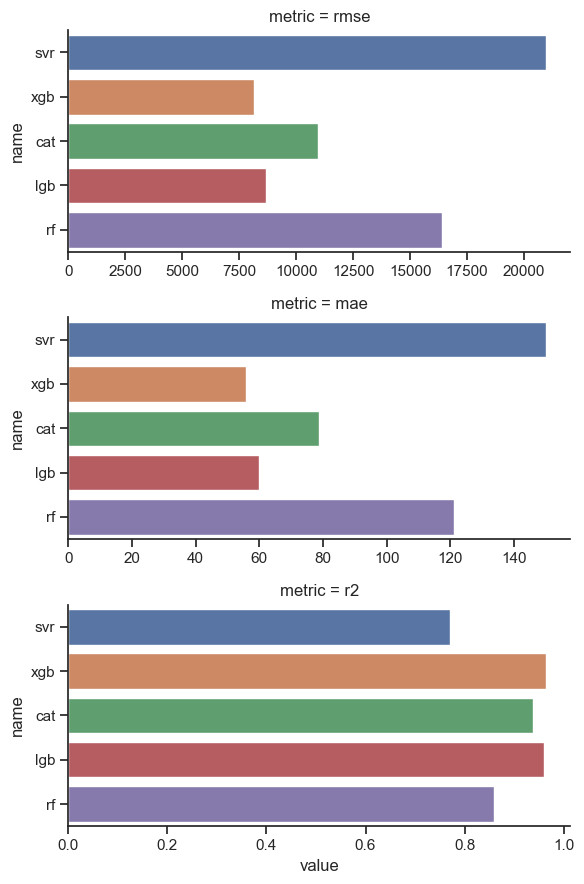

In [18]:
g = sns.FacetGrid(
    model_metrics, row="metric", sharex=False, height=3, aspect=2, hue="name"
)
g.map(sns.barplot, "value", "name", order=model_metrics["name"].unique())

<Axes: xlabel='y_test', ylabel='y_pred'>

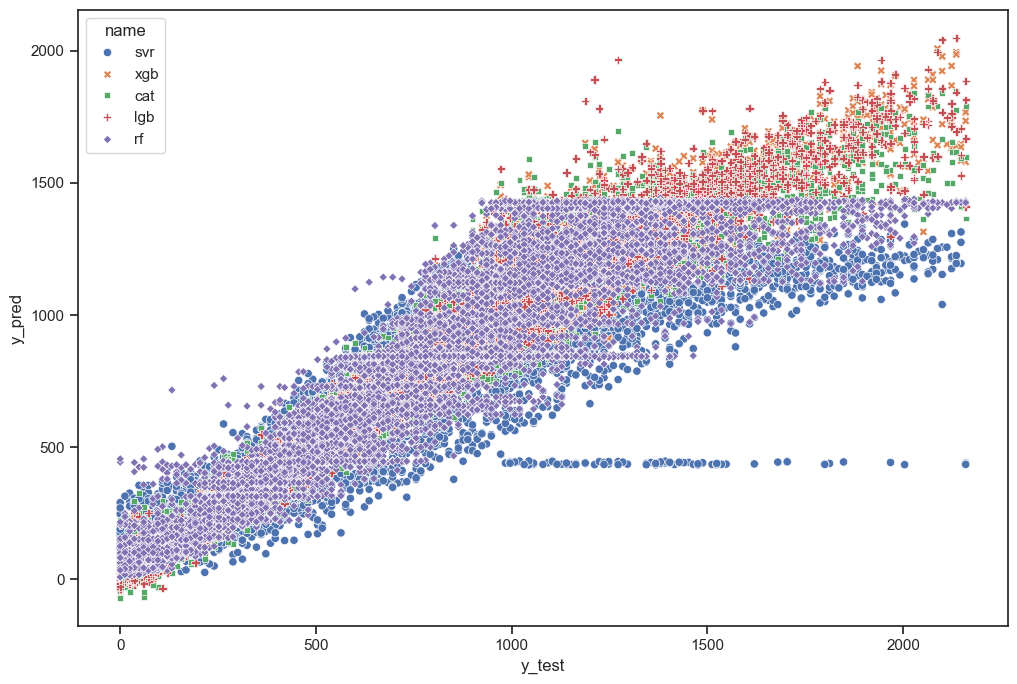

In [19]:
fig, ax = plt.subplots(figsize=(12, 8))
sns.scatterplot(
    data=model_preds,
    x="y_test",
    y="y_pred",
    hue="name",
    style="name",
    ax=ax,
)

## experimentation
Use the experimental `DataFrame` to make some predictions

In [20]:
import glob

In [ ]:
# Glob xgb cv file and load the model, since the time is unknown
xgb_choices = glob.glob("xgb_*", root_dir=MODEL_DIR)
best_xgb = jl.load(os.path.join(MODEL_DIR, xgb_choices[-1]))

# Glob cat cv file and load the model, since the time is unknown
cat_choices = glob.glob("cat_*", root_dir=MODEL_DIR)
best_cat = jl.load(os.path.join(MODEL_DIR, cat_choices[-1]))

# Scale the experimental data using the same scaler as before
df_experimental = df_experimental.drop(columns=["timestamp", "lift_model", "maintenance_done", "RUL_hrs"])
# df_experimental
df_experimental = scaler.transform(df_experimental)

In [27]:
trial = df_experimental[0].reshape(1, -1)
xgb_preds = best_xgb.predict(trial)
cat_preds = best_cat.predict(trial)
scaler.inverse_transform(trial), xgb_preds, cat_preds

(array([[ 1.00000e+00,  2.54784e+05,  5.01000e-01,  2.15400e+00,
          1.09000e-01,  1.03050e+01,  3.48540e+01, -5.70000e-02,
         -4.88900e-01, -6.01100e-01, -5.25400e-01, -1.29610e+00]]),
 array([1205.5723], dtype=float32),
 array([1274.73434601]))